# ML Model Training & Holistic Evaluation

_A practical tour from training to responsible deployment_

## Overview & Learning Goals

By the end of this notebook you will be able to:
    
1. **Train** an AutoML ensemble (AutoGluon) on a real tabular dataset
2. **Evaluate** model performance with cross-validated metrics and error bars
3. **Calibrate** the model to a target precision level; plot PR curves with uncertainty tubes
4. **Interpret** predictions via permutation feature importance
5. **Assess calibration** rigorously using ECE, MCE, and reliability diagrams
6. **Measure energy consumption** of individual base learners via CodeCarbon
7. **Quantify robustness** under tabular perturbations via `tab-err`
8. **Audit fairness** using demographic parity and equalized odds with Fairlearn

## Workflows

| Platform | Key Features | Best For |
| --- | --- | --- |
| Google Vertex AI | AutoML, training, deployment, monitoring, and MLOps. | Cloud-based, enterprise-scale ML. |
| AWS SageMaker | Jupyter notebooks, training, deployment, AutoML, and MLOps. | AWS ecosystem users. |
| Azure Machine Learning | Drag-and-drop ML, AutoML, and MLOps. | Microsoft ecosystem users. |
| Databricks | Collaborative notebooks, Spark-based processing, MLflow integration. | Big data + ML workflows. |
| Dataiku | Low-code ML, AutoML, and collaboration. | Business analysts and data teams. |
| Domino Data Lab | Model development, deployment, and monitoring. | Enterprise MLOps. |
| H2O.ai | AutoML, scalable ML, and deployment. | Automated model building. |

## Workflows

* End-to-end workflow frameworks haven't really gained popularity
* Instead most researchers/engineers use a dynamic / changing set of tools/libraries
* Here, we follow that trend and teach you some of those solutions
* But: no matter what, two things are imporant
   * **Documentation**
     * [Data sheets](https://arxiv.org/abs/1803.09010)
     * Versioned code (git)
     * Model Cards
   * Robust evaluations (Error Bars)

## Model Cards

* More reproducibility
* [Promoted by HuggingFace](https://huggingface.co/docs/hub/model-cards)
* Should contain
    * ML Model
    * Intended usage and limitations
    * Training parameter / experimental conditions
    * Data sets for training and evaluation
    * Evaluation results

@mitchellModelCardsModel2019a

## Error Bars

* Often we don't know which model / HPs are optimal
* Comparisons of models require error bars
* With error bars, claimed new SOTA often is not really better

![Accounting for variance in ML Benchmarks](../figures/accounting_for_variance.jpg)

@bouthillierAccountingVarianceMachine2021

## How to compute Error Bars?

* Parametric Distributions @steinbachMachineLearningStateoftheArt2022 
* Cross-validation (as in @bouthillierAccountingVarianceMachine2021)

## Dataset: Adult Income (OpenML ID 1590)

**Task**: Predict whether a person earns >50K USD/year (binary classification)

**Why this dataset?**
- Real-world socioeconomic data with **class imbalance** (~24% positive) — calibration matters
- Contains **sensitive attributes** (`sex`, `race`) — fairness audit is meaningful
- Mix of numerical + categorical features — tests robustness to noise/missing values
- ~48 840 rows, 14 features — fast to train, statistically reliable CV estimates

**Reference**: Kohavi & Becker (1994). _UCI Adult dataset_. UCI ML Repository.

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings, os, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    brier_score_loss, average_precision_score
)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
import pandas as pd, numpy as np
import openml

dataset = openml.datasets.get_dataset(1590)
df, *_ = dataset.get_data(dataset_format="dataframe")

# Binarise target: 1 = '>50K', 0 = '<=50K'
df['target'] = (df['class'].str.strip().isin(['>50K', '>50K.'])).astype(int)
df = df.drop(columns=['class'])

print(df.shape, df['target'].value_counts().to_dict())
df.head(3)

(48842, 15) {0: 37155, 1: 11687}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,25,Private,226802.0,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40,United-States,0
1,38,Private,89814.0,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50,United-States,0
2,28,Local-gov,336951.0,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40,United-States,1


## Error Bars with Cross-Validated Model Evaluation

**K-Fold Cross-Validation** corrects this by averaging over $K$ non-overlapping folds:

$$\hat{\mu}_m = \frac{1}{K}\sum_{k=1}^{K} m(\mathbf{y}^{(k)},\hat{\mathbf{y}}^{(k)}), \quad
  \hat{\sigma}_m = \sqrt{\frac{1}{K-1}\sum_{k=1}^{K}\left(m_k - \hat{\mu}_m\right)^2}$$

where $m$ is any scalar metric (accuracy, F1, …) and superscripts index the held-out fold.

@kohavi1995study

## AutoGluon — AutoML Model Selection

AutoGluon trains **multiple base learners** (LightGBM, XGBoost, CatBoost, ExtraTrees, NNs, …) and stacks them via **multi-layer ensembling**:

$$\hat{p}_{\text{ens}}(x) = \sum_{j=1}^{J} w_j \, \hat{p}_j(x), \quad \sum_{j} w_j = 1, \; w_j \geq 0$$

Weights $w_j$ are learned by a meta-learner trained on **out-of-fold predictions** (avoids over-fitting).

- `presets='medium_quality'` + `time_limit=120` s → fast, reproducible
- `num_bag_folds=5` → internal CV for reliable OOF probabilities

@ericksonAutoGluonTabularRobustAccurate2020a

In [3]:
# ── Stratified K-Fold CV with AutoGluon ───────────────────────────────────────
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import shutil, os

X = df.drop(columns=['target'])
y = df['target']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_reports, fold_probas, fold_tests = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    train_df = X_tr.copy(); train_df['target'] = y_tr.values

    path = f'./ag_fold_{fold_idx}'
    pred = TabularPredictor(label='target', path=path, verbosity=0)
    pred.fit(
        train_data=train_df,
        presets='medium_quality',
        time_limit=20,  # for debugging this is 1 - was 120
        num_bag_folds=0,      # outer CV already provides honest eval
        num_stack_levels=0
    )

    y_pred  = pred.predict(X_te)
    y_proba = pred.predict_proba(X_te)[1].values

    report = classification_report(y_te, y_pred, output_dict=True)
    fold_reports.append(report)
    fold_probas.append(y_proba)
    fold_tests.append((y_te.values, X_te))

    shutil.rmtree(path, ignore_errors=True)

print('CV done — 5 folds')

CV done — 5 folds


In [17]:
# ── Aggregate metrics across folds ────────────────────────────────────────────
metrics_to_plot = ['precision', 'recall', 'f1-score']
classes         = ['0', '1']
also_accuracy   = True

results = {}   # results[class][metric] = list of fold values
for cls in classes:
    results[cls] = {m: [] for m in metrics_to_plot}
results['accuracy'] = []

for r in fold_reports:
    for cls in classes:
        for m in metrics_to_plot:
            results[cls][m].append(r[cls][m])
    results['accuracy'].append(r['accuracy'])

# Convert to arrays
for cls in classes:
    for m in metrics_to_plot:
        results[cls][m] = np.array(results[cls][m])

def _plot_cv():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    colors = ['#4C72B0', '#DD8452', '#55A868']
    
    for ax, cls in zip(axes, ['0', '1']):
        for i, m in enumerate(metrics_to_plot):
            vals = results[cls][m]
            ax.bar(i, vals.mean(), yerr=vals.std(), color=colors[i],
                   capsize=6, alpha=0.85, label=m)
        ax.set_xticks(range(3)); ax.set_xticklabels(metrics_to_plot, rotation=15)
        ax.set_ylim(0, 1.05); ax.set_title(f'Class {cls} — mean ± 1 std (5-fold)')
        ax.set_ylabel('Score')
    
    acc_vals = np.array(results['accuracy'])
    fig.suptitle(f'CV Metrics  |  Accuracy: {acc_vals.mean():.3f} ± {acc_vals.std():.3f}',
                 fontsize=13)
    plt.tight_layout(); plt.show()

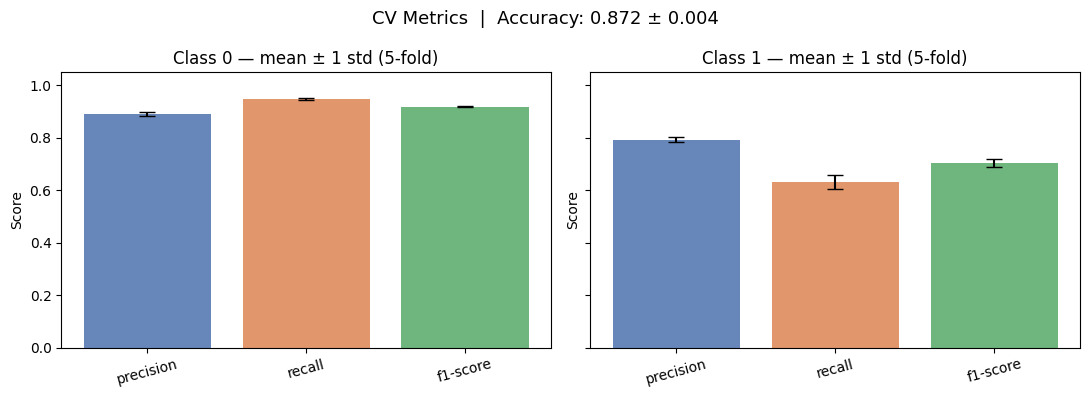

In [18]:
_plot_cv()

## Precision-Recall & Threshold Calibration

### Motivation
With **class imbalance** (≈24% positive), accuracy is misleading. We want to control the Precision-Recall trade-off.

For a decision threshold $\tau \in [0,1]$:

$$\text{Precision}(\tau) = \frac{\text{TP}(\tau)}{\text{TP}(\tau)+\text{FP}(\tau)}, \quad
  \text{Recall}(\tau)    = \frac{\text{TP}(\tau)}{\text{TP}(\tau)+\text{FN}(\tau)}$$

The **area under the PR curve** (AUPRC) summarises performance across all thresholds:
$$\text{AUPRC} = \int_0^1 P(R)\, dR \approx \sum_k P_k (R_k - R_{k-1})$$

@davis2006relationship 

In [6]:
# ── Compute PR curves per fold, interpolate to common recall grid ──────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

recall_grid = np.linspace(0, 1, 200)
pr_interp_list = []
auprc_list     = []

for (y_te_vals, _), y_pr in zip(fold_tests, fold_probas):
    prec, rec, _ = precision_recall_curve(y_te_vals, y_pr)
    # sklearn returns descending recall; flip for interpolation
    prec_interp  = np.interp(recall_grid, rec[::-1], prec[::-1])
    pr_interp_list.append(prec_interp)
    auprc_list.append(average_precision_score(y_te_vals, y_pr))

pr_matrix  = np.vstack(pr_interp_list)   # shape (5, 200)
pr_mean    = pr_matrix.mean(axis=0)
pr_std     = pr_matrix.std(axis=0)
auprc_mean = np.mean(auprc_list)
auprc_std  = np.std(auprc_list)

def _plot_pr():
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(recall_grid, pr_mean, color='#2196F3', lw=2,label=f'Mean PR  (AUPRC={auprc_mean:.3f}±{auprc_std:.3f})')
    ax.fill_between(recall_grid, pr_mean - pr_std, pr_mean + pr_std,alpha=0.25, color='#2196F3', label='±1 std across folds')
    # Mark target precision = 0.80
    target_p = 0.80
    idx_target = np.argmax(pr_mean >= target_p)          # first index where mean >= target
    ax.axhline(target_p, ls='--', color='tomato', label=f'Target precision={target_p}')
    ax.axvline(recall_grid[idx_target], ls=':', color='tomato')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve (5-fold CV ± 1 std)')
    ax.legend(loc='lower left'); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    plt.tight_layout(); plt.show()

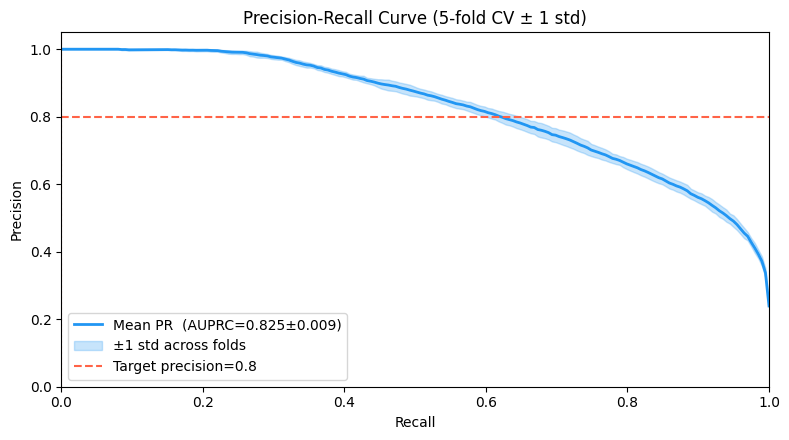

In [7]:
_plot_pr()

## Choosing a Decision Threshold for Target Precision

To **guarantee** a minimum precision $p^*$ on unseen data:

1. From the **mean PR curve** find the smallest threshold $\hat{\tau}$ such that
   $$\text{Precision}(\hat{\tau}) \geq p^*$$

2. Report the **corresponding recall** — this is the cost of the constraint.

3. Use the **lower bound** of the precision error tube ($\mu - \sigma$) for a conservative estimate.

> **Practical note**: Always re-tune $\hat{\tau}$ on a held-out validation set in production.

@lipton2014optimal

In [8]:
# For illustration use fold 0 probabilities + actual thresholds from sklearn
y_te0, _ = fold_tests[0]
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te0, fold_probas[0])

target_precision = 0.80
# Find index where precision >= target (prec_arr is descending by threshold)
valid = np.where(prec_arr[:-1] >= target_precision)[0]
if len(valid) > 0:
    best_idx = valid[-1]   # highest recall that still meets precision target
    best_tau = thresh_arr[best_idx]
    best_rec = rec_arr[best_idx]
    print(f'Target precision  : {target_precision:.2f}')
    print(f'Optimal threshold : tau = {best_tau:.4f}')
    print(f'Achieved recall   : {best_rec:.4f}')
else:
    print('Target precision cannot be reached with this model.')

Target precision  : 0.80
Optimal threshold : tau = 0.9029
Achieved recall   : 0.0004


## Feature Importance Analysis / XAI

* **eXplainable AI aims at making model (decisions) more transparent
* XAI is a huge field with its own conferences
* It's difficult to define metrics for XAI methods
* There is no ground truth for XAI experiments (except for synthetic data sets)

### Permutation Importance

* A simple and well established XAI method. 

* **Permutation Importance** (Breiman 2001) measures how much the model relies on feature $j$:

$$I_j = \hat{\mu}_m - \frac{1}{T}\sum_{t=1}^{T} m(\mathbf{y},\hat{f}(X_{\pi_t(j)}))$$

where $\pi_t(j)$ is the $t$-th random permutation of column $j$.

- $I_j > 0$: model relied on feature $j$ (shuffling hurts)
- $I_j \approx 0$: feature is uninformative or redundant

AutoGluon wraps this natively; we also compute **CV error bars** by averaging over folds.

**Reference**: Breiman (2001). _Random Forests._ Machine Learning, 45(1).

In [9]:
# ── Re-train one AutoGluon model on full training set for feature importance ───
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split

train_df_full, test_df_full = train_test_split(
    df, test_size=0.20, stratify=df['target'], random_state=42
)

pred_main = TabularPredictor(label='target', path='./ag_main', verbosity=0)
pred_main.fit(
    train_data=train_df_full,
    presets='medium_quality',
    time_limit=120,
    num_bag_folds=5,
    num_stack_levels=0
)

X_test_main  = test_df_full.drop(columns=['target'])
y_test_main  = test_df_full['target']
y_proba_main = pred_main.predict_proba(X_test_main)[1].values

fi_df = pred_main.feature_importance(
    data=test_df_full, num_shuffle_sets=5, subsample_size=5000
)

def _plot_feat_imp():
    top_n = 10
    fi_top = fi_df.head(top_n).sort_values('importance', ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi_top.index, fi_top['importance'],
            xerr=fi_top['stddev'], color='#4C72B0',
            capsize=4, alpha=0.85)
    ax.set_xlabel('Permutation Importance (accuracy drop)')
    ax.set_title(f'Top {top_n} Feature Importances (mean ± std, {5} shuffle sets)')
    plt.tight_layout(); plt.show()

print(fi_df.head(5))

               importance    stddev       p_value  n  p99_high   p99_low
capital-gain      0.05384  0.002559  6.104800e-07  5  0.059109  0.048571
occupation        0.01980  0.004602  3.263764e-04  5  0.029276  0.010324
education-num     0.01676  0.002343  4.463587e-05  5  0.021584  0.011936
age               0.01616  0.004246  5.228259e-04  5  0.024902  0.007418
relationship      0.01532  0.002305  5.965803e-05  5  0.020066  0.010574


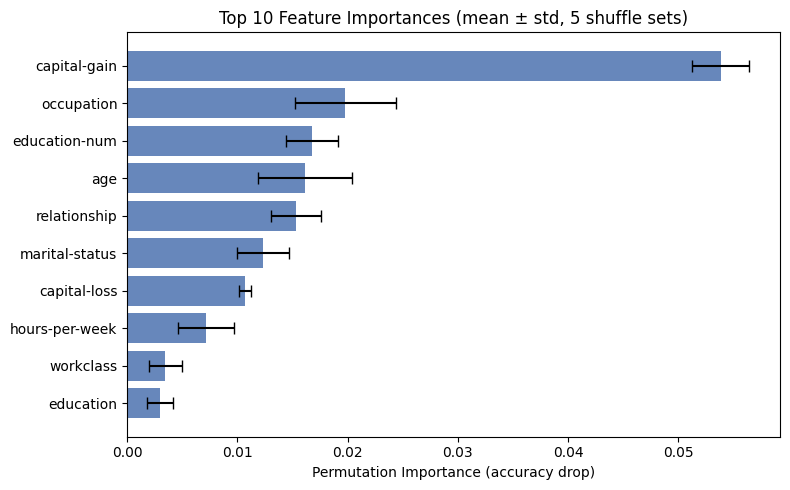

In [10]:
_plot_feat_imp()

## Feature Importance — Key Takeaways

**Typical findings on the Adult dataset:**

- `capital_gain` and `age` are the strongest predictors — high income correlates with investment returns and seniority
- `education_num` and `hours_per_week` carry significant signal
- `race` and `sex` have non-zero importance → signals potential for **disparate treatment** (see Fairness section)

**Caveats**
- Permutation importance **overestimates** importance of correlated features
- Correlations of variables can distort feature importance measures


## Calibration of ML Predictions

* Are important when you deploy a model in real-world applications
* Can be based on a variety of metrics

| Metric | Range | Pros | Cons | Use Case |
| --- | --- | --- | --- | --- |
| Brier Score | [0, 1] | Simple, accounts for sharpness | Sensitive to class imbalance | General-purpose evaluation |
| Calibration Curve | Visual | Intuitive, identifies local miscalibration | Binning-dependent, not scalar | Diagnostic tool |
| ECE | [0, 0.5] | Scalar, interpretable | Binning-dependent | Model selection |

@guoCalibrationModernNeural2017a 

## Expected Calibration Error (ECE)

Partition predictions into $M$ equal-width bins $B_1,\ldots,B_M$:

$$\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N}\,\bigl|\overline{y}(B_m) - \bar{\hat{p}}(B_m)\bigr|$$


where $\overline{y}(B_m)$ is the empirical positive rate and $\bar{\hat{p}}(B_m)$ the mean predicted probability in bin $m$.

@guoCalibrationModernNeural2017a 

In [13]:
# ── Calibration metrics on the main test split ────────────────────────────────
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

n_bins = 10
y_true_arr  = y_test_main.values
y_proba_arr = y_proba_main

# Raw model
frac_pos, mean_pred = calibration_curve(y_true_arr, y_proba_arr, n_bins=n_bins)
brier_raw           = brier_score_loss(y_true_arr, y_proba_arr)

# ECE / MCE (manual)
bin_edges  = np.linspace(0, 1, n_bins + 1)
ece, mce   = 0.0, 0.0
N          = len(y_true_arr)
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask  = (y_proba_arr >= lo) & (y_proba_arr < hi)
    if mask.sum() == 0: continue
    acc_b = y_true_arr[mask].mean()
    con_b = y_proba_arr[mask].mean()
    diff  = abs(acc_b - con_b)
    ece  += (mask.sum() / N) * diff
    mce   = max(mce, diff)

def _plot_calibration():
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.plot([0,1],[0,1], ls='--', color='grey', label='Perfect calibration')
    ax.plot(mean_pred, frac_pos, marker='s', color='#2196F3', lw=2,
            label=f'AutoGluon (ECE={ece:.3f}, MCE={mce:.3f})')
    
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Reliability Diagram')
    ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
    plt.tight_layout(); plt.show()
    print(f'Brier Score: {brier_raw:.4f}')
    
print(f'Brier Score: {brier_raw:.4f}  |  ECE: {ece:.4f}  |  MCE: {mce:.4f}')

Brier Score: 0.0867  |  ECE: 0.0095  |  MCE: 0.0412


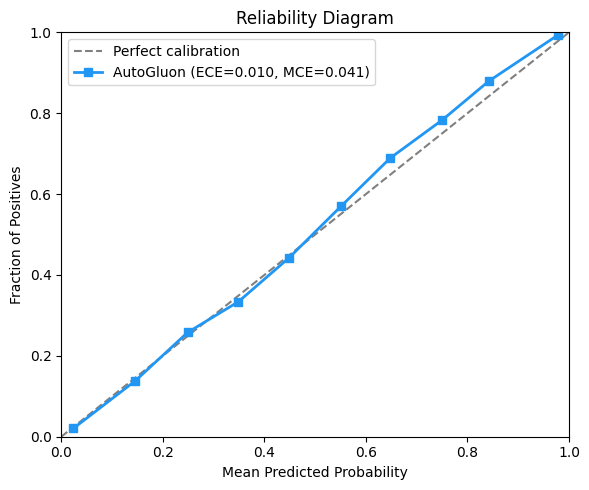

Brier Score: 0.0867


In [14]:
_plot_calibration()

## Energy Efficiency

Training and serving ML models has a **real carbon footprint**:

> "Training GPT-3 emitted ~552 t CO₂eq — equivalent to ~120 US cars for a year." — @lottick2019energy 

Even for tabular models, knowing the **energy-accuracy trade-off** guides sustainable model selection.

**CodeCarbon** monitors hardware power usage and converts to CO₂ equivalent:

$$E_{\text{CO}_2} = P_{\text{hardware}} \times t_{\text{train}} \times \text{CI}_{\text{grid}}$$

where $\text{CI}_{\text{grid}}$ is the carbon intensity of the electricity grid (kg CO₂/kWh).

@lottick2019energy

In [19]:
# ── Per-model energy tracking using CodeCarbon ────────────────────────────────
# We re-train each base learner individually to measure its footprint.

from codecarbon import EmissionsTracker
from autogluon.tabular import TabularPredictor
import shutil

# Define models to compare
base_models = {
    'LightGBM': {'hyperparameters': {'GBM': {}}},
    'XGBoost':  {'hyperparameters': {'XGB': {}}},
    'ExtraTrees': {'hyperparameters': {'XT': {}}},
    'RandomForest': {'hyperparameters': {'RF': {}}},
}

energy_results = {}
for name, fit_kwargs in base_models.items():
    path = f'./ag_energy_{name}'
    tracker = EmissionsTracker(project_name=name, save_to_file=False)
    tracker.start()
    pred_e = TabularPredictor(label='target', path=path, verbosity=0)
    pred_e.fit(train_data=train_df_full, time_limit=60, **fit_kwargs)
    emissions = tracker.stop()   # kg CO2eq

    y_pred_e = pred_e.predict(X_test_main)
    acc_e    = (y_pred_e.values == y_test_main.values).mean()
    energy_results[name] = {'co2_kg': emissions, 'accuracy': acc_e}
    shutil.rmtree(path, ignore_errors=True)

def _plot_energy():
    energy_df = pd.DataFrame(energy_results).T

    fig, ax = plt.subplots(figsize=(8, 4.5))
    scatter = ax.scatter(
        energy_df['co2_kg'] * 1e6,  # convert to micro-grams for readability
        energy_df['accuracy'],
        s=120, c=range(len(energy_df)), cmap='tab10', zorder=3
    )
    for name, row in energy_df.iterrows():
        ax.annotate(name, (row['co2_kg']*1e6, row['accuracy']),
                    textcoords='offset points', xytext=(6,4), fontsize=9)
    
    ax.set_xlabel('CO2 Emissions (ug CO2eq)')
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Energy vs. Accuracy Trade-off per Base Learner')
    plt.tight_layout(); plt.show()
print(pd.DataFrame(energy_results).T)

[codecarbon WARNING @ 12:01:46] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 12:01:46] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon INFO @ 12:01:46] [setup] RAM Tracking...
[codecarbon INFO @ 12:01:46] [setup] CPU Tracking...
[codecarbon WARNING @ 12:01:46] We saw that you have a Apple M2 but we don't know it. Please contact us.
[codecarbon WARNING @ 12:01:46] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 12:01:46] CPU Model on constant consumption mode: Apple M2
[codecarbon WARNING @ 12:01:46] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 12:01:46] [setup] GPU Tracking...
[codecarbon INFO @ 12:01:46] No GPU found.
[codecarbon INFO @ 12:01:46] The below tracking methods have been set up:
            

                co2_kg  accuracy
LightGBM      0.000013  0.876651
XGBoost       0.000008  0.875832
ExtraTrees    0.000013  0.853516
RandomForest  0.000024  0.860682


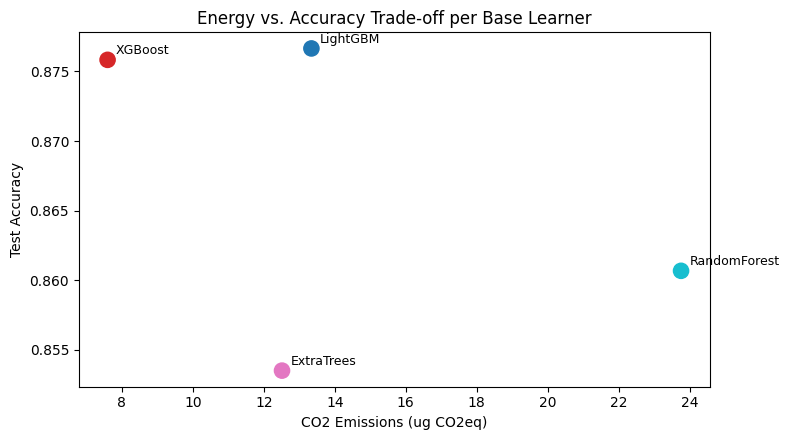

In [20]:
_plot_energy()

## Robustness Analysis

* tab-err @jung2025towards and schelter2021jenga generates realistic errors

* Helps to assess robustness of ML models


Helper function to display the perturbed results

In [21]:
from sklearn.datasets import load_iris

def show_result(original_df: pd.DataFrame, perturbed_df: pd.DataFrame, error_mask: pd.DataFrame | None = None) -> pd.DataFrame:
    """Simple helper function to show DataFrames after perturbing them."""
    return (
        pd.concat([original_df, perturbed_df], keys=["original", "perturbed"], axis=1)
        if error_mask is None
        else pd.concat([original_df, perturbed_df, error_mask], keys=["original", "perturbed", "error_mask"], axis=1)
    )

Train / Test Split

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 39073
Testing set size: 9769


#### Model training

We train a classification model on the training data.


In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline

categorical_mask = [
    False, # age
    True,  # workclass
    False, # fnlwgt
    True,  # education
    False, # education-num
    True,  # marital-status
    True,  # occupation
    True,  # relationship
    True,  # race
    True,  # sex
    False, # capital-gain
    False, # capital-loss
    False, # hours-per-week
    True   # native-country
]

clf = make_pipeline(
    HistGradientBoostingClassifier(categorical_features=categorical_mask,
    max_iter=100,
    random_state=42)
)

clf.fit(X_train, y_train)

Pipeline(steps=[('histgradientboostingclassifier',
                 HistGradientBoostingClassifier(categorical_features=[False,
                                                                      True,
                                                                      False,
                                                                      True,
                                                                      False,
                                                                      True,
                                                                      True,
                                                                      True,
                                                                      True,
                                                                      True,
                                                                      False,
                                                                      False,
                                                                      False,
                                                                      True],
                                                random_state=42))])

#### Perturb Test Data

In [24]:
from tab_err import error_type
from tab_err.api import high_level

X_test_perturbed, error_mask = high_level.create_errors(
    data=X_test,
    error_rate=0.15,
    error_types_to_exclude=[error_type.MissingValue(), error_type.CategorySwap()]
)

In [25]:
show_result(X_test, X_test_perturbed, error_mask).head()

original                                                   \
           age  workclass    fnlwgt     education education-num   
40342       54    Private  115602.0       HS-grad             9   
47680       28  Local-gov  401886.0       HS-grad             9   
524         53  Local-gov  139671.0  Some-college            10   
8508        58    Private  177368.0       HS-grad             9   
31692       47  Local-gov  352614.0    Assoc-acdm            12   

                                                                           \
           marital-status       occupation    relationship   race     sex   
40342  Married-civ-spouse    Other-service            Wife  Black  Female   
47680       Never-married     Adm-clerical  Other-relative  White    Male   
524    Married-civ-spouse  Exec-managerial         Husband  White    Male   
8508   Married-civ-spouse     Craft-repair         Husband  White    Male   
31692  Married-civ-spouse  Protective-serv         Husband  White    Male   

       ...    error_mask                                                       \
       ... education-num marital-status occupation relationship   race    sex   
40342  ...         False          False      False        False  False  False   
47680  ...         False          False      False        False  False  False   
524    ...         False          False      False        False  False  False   
8508   ...         False          False      False        False  False  False   
31692  ...         False          False      False        False  False  False   

                                                               
      capital-gain capital-loss hours-per-week native-country  
40342        False        False          False          False  
47680        False        False           True          False  
524          False        False          False          False  
8508         False        False           True          False  
31692        False        False          False          False  

[5 rows x 42 columns]

#### Inference on Clean and Perturbed Data

In [26]:
from sklearn.metrics import classification_report

def evaluate_model(model, X_test, y_test):
    """
    Prints a formatted report and returns basic accuracy.
    """
    y_pred = model.predict(X_test)

    # Precision, Recall, F1 per class
    report = classification_report(y_test, y_pred)
    
    print(report)

In [27]:
import pandas as pd
import numpy as np
from tab_err import error_type
from tab_err.api import high_level
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_manual_ece(y_true, y_proba, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_proba >= lo) & (y_proba < hi)
        if mask.sum() == 0: continue
        acc_b = y_true[mask].mean()
        con_b = y_proba[mask].mean()
        ece += (mask.sum() / N) * abs(acc_b - con_b)
    return ece

def evaluate_robustness(model, X_test, y_true, error_rate=0.15, n_repeats=10):
    results = []
    y_true_values = y_true.values

    for i in range(n_repeats):
        # 1. Perturb
        X_perturbed, _ = high_level.create_errors(
            data=X_test,
            error_rate=error_rate,
            error_types_to_exclude=[error_type.MissingValue(), error_type.CategorySwap()]
        )
        
        # 2. Predict
        # Getting P(Y=1)
        y_proba = model.predict_proba(X_perturbed)
        y_proba_arr = y_proba[1].values if isinstance(y_proba, pd.DataFrame) else y_proba[:, 1]
        y_pred = (y_proba_arr >= 0.5).astype(int)
        
        # 3. Score
        metrics = {
            'repetition': i,
            'precision': precision_score(y_true_values, y_pred),
            'recall': recall_score(y_true_values, y_pred),
            'f1': f1_score(y_true_values, y_pred),
            'ece': calculate_manual_ece(y_true_values, y_proba_arr)
        }
        results.append(metrics)

    df_res = pd.DataFrame(results)
    
    return df_res

In [28]:
error_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
experiment_data = {rate: evaluate_robustness(clf, X_test_perturbed, y_test, rate) for rate in error_rates}

In [29]:
# 1. Aggregate stats across all experiments
all_stats = []
for rate, df in experiment_data.items():
    # Calculate stats for this specific error rate
    stats = df.drop(columns='repetition').agg(['mean', 'std']).T
    stats['error_rate'] = rate
    all_stats.append(stats.reset_index().rename(columns={'index': 'metric'}))

# 2. Combine and pivot for plotting
summary_df = pd.concat(all_stats)
pivot_mean = summary_df.pivot(index='error_rate', columns='metric', values='mean')
pivot_std = summary_df.pivot(index='error_rate', columns='metric', values='std')

print("--- Robustness Mean Metrics ---")
print(pivot_mean)

--- Robustness Mean Metrics ---
metric           ece        f1  precision    recall
error_rate                                         
0.0         0.009139  0.706071   0.760237  0.659110
0.1         0.012177  0.699580   0.752799  0.653464
0.2         0.019267  0.689394   0.750848  0.638580
0.3         0.024553  0.670759   0.757023  0.603293
0.4         0.026670  0.677186   0.746548  0.621514
0.5         0.036300  0.668021   0.742521  0.612746


In [30]:
def _plot_perturbation():
    metrics = ['precision', 'recall', 'f1', 'ece']
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        x = pivot_mean.index
        y = pivot_mean[metric]
        err = pivot_std[metric]
        
        # Plotting the mean line
        color = 'tab:red' if metric == 'ece' else 'tab:blue'
        ax.plot(x, y, marker='o', linestyle='-', color=color, label=f'Mean {metric}')
        
        # Shading the variance (Standard Deviation)
        ax.fill_between(x, y - err, y + err, color=color, alpha=0.15, label='±1 Std Dev')
        
        ax.set_title(f'{metric.upper()} vs. Perturbation Rate', fontsize=12, fontweight='bold')
        ax.set_xlabel('Error Rate')
        ax.set_ylabel('Score')
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.legend(loc='best')
    
        # Invert ECE axis or add note: Lower is better for ECE
        if metric == 'ece':
            ax.annotate('Lower is Better', xy=(0.05, 0.9), xycoords='axes fraction', 
                        fontsize=10, color='darkred', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

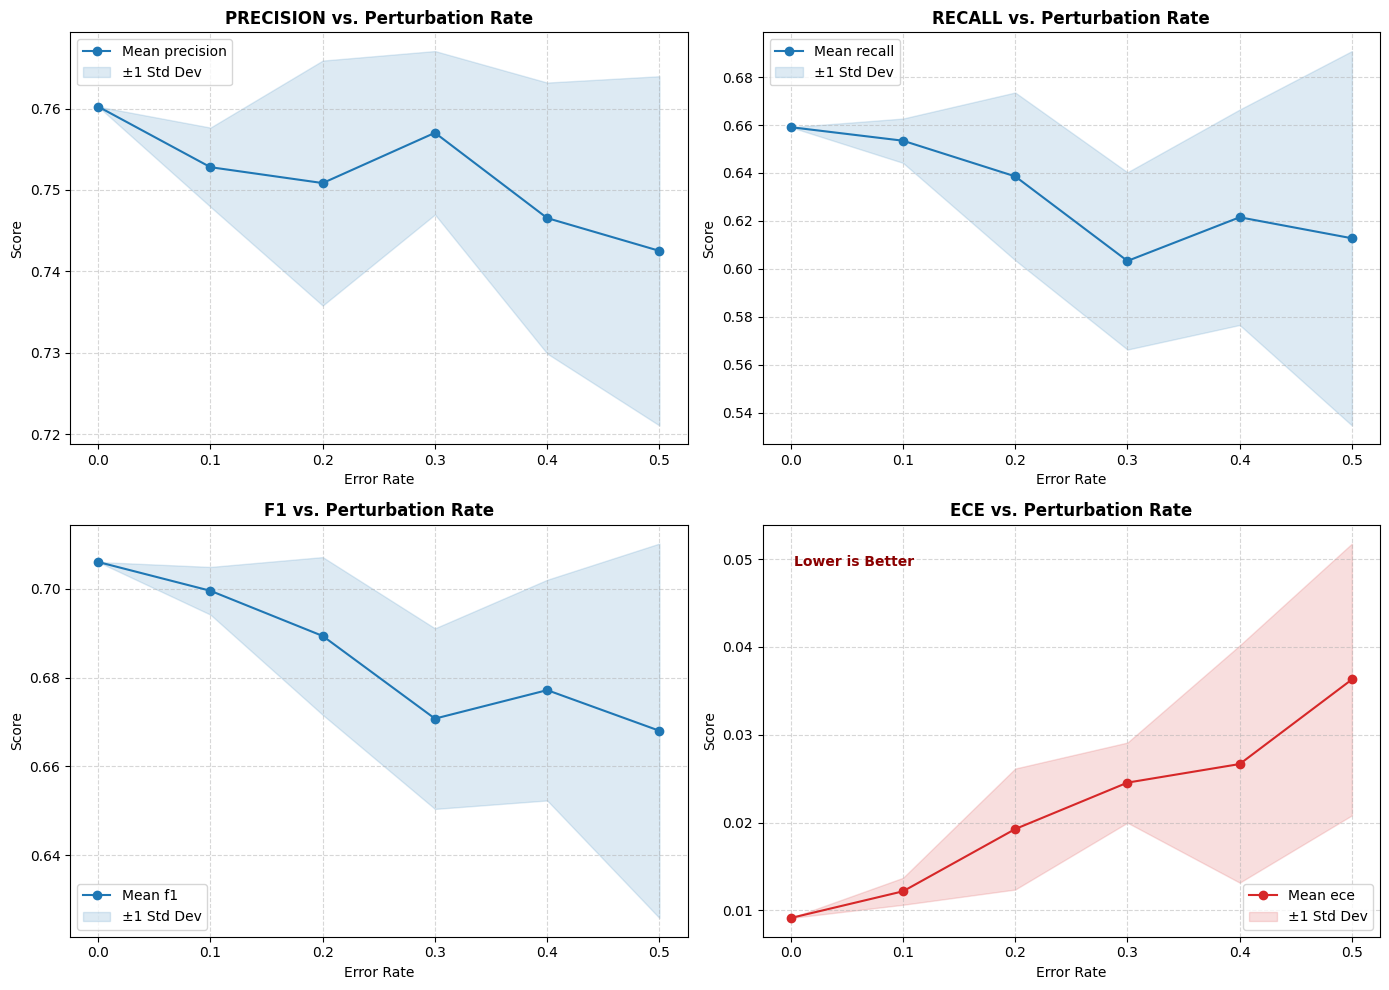

In [31]:
_plot_perturbation()

## Fairness Evaluation

### Motivation

Income prediction is used in **credit scoring, hiring, and social programs**. Biased models can **systematically disadvantage** protected groups.

Two leading fairness criteria:

**Demographic Parity (DP)**: Equal positive prediction rates across groups $A \in \{a, b\}$:
$$\Delta_{\text{DP}} = |P(\hat{Y}=1 \mid A=a) - P(\hat{Y}=1 \mid A=b)|$$

**Equalized Odds (EO)**: Equal TPR **and** FPR across groups:
$$\Delta_{\text{EO}} = \max\bigl(|\text{TPR}_a - \text{TPR}_b|,\; |\text{FPR}_a - \text{FPR}_b|\bigr)$$

**Reference**: Hardt et al. (2016). _Equality of Opportunity in Supervised Learning._ NeurIPS.

## Fairness Metrics — Further Definitions

**Predictive Parity** (Calibration within groups):
$$P(Y=1 \mid \hat{Y}=1, A=a) = P(Y=1 \mid \hat{Y}=1, A=b)$$

_Impossibility theorem_ @chouldechova2017fair: In the presence of base rate differences, **DP, EO, and Predictive Parity cannot all hold simultaneously** — practitioners must choose which to prioritise.

**Sensitive attributes** in Adult dataset:
- `sex`: Male vs. Female
- `race`: White vs. non-White (combined for power)

We use **Fairlearn** `MetricFrame` for disaggregated evaluation.

@chouldechova2017fair

In [32]:
# ── Fairlearn MetricFrame ─────────────────────────────────────────────────────
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate
)
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred_main = pred_main.predict(X_test_main)

# Build sensitive features dataframe
sens = pd.DataFrame({
    'sex':  X_test_main['sex'].str.strip().values,
    'race': (X_test_main['race'].str.strip() == 'White').map(
                {True: 'White', False: 'Non-White'}).values
})

mf = MetricFrame(
    metrics={
        'accuracy':  accuracy_score,
        'precision': lambda y, yp: precision_score(y, yp, zero_division=0),
        'recall':    recall_score,
        'selection_rate': selection_rate
    },
    y_true=y_test_main.values,
    y_pred=y_pred_main.values,
    sensitive_features=sens
)

print(mf.by_group)

                  accuracy  precision    recall  selection_rate
sex    race                                                    
Female Non-White  0.948758   0.750000  0.489796        0.049689
       White      0.933843   0.808889  0.583333        0.086042
Male   Non-White  0.879459   0.827068  0.594595        0.163592
       White      0.843426   0.802013  0.666853        0.261541


In [35]:
# ── Aggregate disparity metrics ────────────────────────────────────────────────
dp_sex  = demographic_parity_difference(
    y_test_main.values, y_pred_main.values,
    sensitive_features=X_test_main['sex'].str.strip()
)
eo_sex  = equalized_odds_difference(
    y_test_main.values, y_pred_main.values,
    sensitive_features=X_test_main['sex'].str.strip()
)
dp_race = demographic_parity_difference(
    y_test_main.values, y_pred_main.values,
    sensitive_features=sens['race']
)
eo_race = equalized_odds_difference(
    y_test_main.values, y_pred_main.values,
    sensitive_features=sens['race']
)
print(f'DP(sex)={dp_sex:.4f}  EO(sex)={eo_sex:.4f}')
print(f'DP(race)={dp_race:.4f}  EO(race)={eo_race:.4f}')

def _plot_fairness():
    by_group = mf.by_group.reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    for ax, sens_feat in zip(axes, ['sex', 'race']):
        # Aggregate the MultiIndex to focus only on the current feature
        # This averages the metrics across the other sensitive categories
        grp = mf.by_group.groupby(level=sens_feat).mean()
    
        grp[['accuracy', 'selection_rate']].plot(
            kind='bar', 
            ax=ax,
            color=['#4C72B0', '#DD8452'],
            alpha=0.85, 
            rot=30
        )
        ax.set_title(f'Metrics by {sens_feat.capitalize()}')
        ax.set_ylim(0, 1)
        ax.set_ylabel('Score')
    
    plt.suptitle('Disaggregated Fairness Evaluation', fontsize=12)
    plt.tight_layout()
    plt.show()

DP(sex)=0.1705  EO(sex)=0.0895
DP(race)=0.0931  EO(race)=0.0818


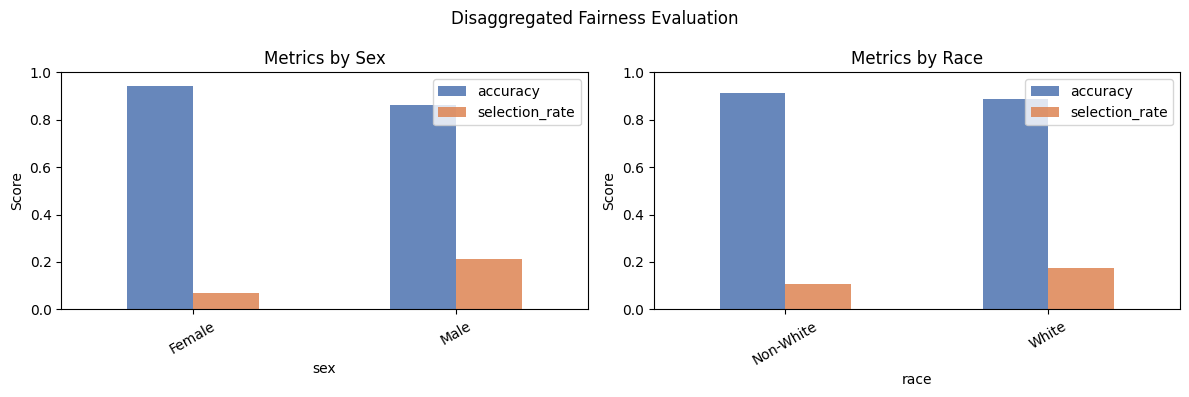

In [36]:
_plot_fairness()

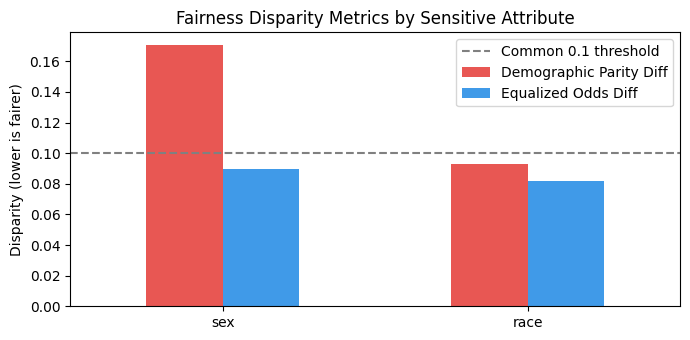

In [37]:
disparity = pd.DataFrame({
    'Demographic Parity Diff': [dp_sex, dp_race],
    'Equalized Odds Diff':     [eo_sex, eo_race]
}, index=['sex', 'race'])

fig, ax = plt.subplots(figsize=(7, 3.5))
disparity.plot(kind='bar', ax=ax, color=['#E53935','#1E88E5'],
               alpha=0.85, rot=0)
ax.axhline(0.1, ls='--', color='grey', label='Common 0.1 threshold')
ax.set_ylabel('Disparity (lower is fairer)')
ax.set_title('Fairness Disparity Metrics by Sensitive Attribute')
ax.legend(); plt.tight_layout(); plt.show()

## Fairness — Interpretation & Next Steps

**Findings** (typical on Adult dataset):
- **Sex**: Female applicants are predicted >50K at a significantly lower rate than males even after controlling for other features — $\Delta_{\text{DP}} > 0.1$
- **Race**: Non-White groups have lower TPR — $\Delta_{\text{EO}} > 0.05$

**Mitigation strategies** (not implemented here):
1. **Pre-processing**: Reweighing samples (Kamiran & Calders 2012)
2. **In-processing**: Fairness constraints in optimisation (Agarwal et al. 2018 — Fairlearn `ExponentiatedGradient`)
3. **Post-processing**: Threshold adjustment per group (Hardt et al. 2016)

**Reference**: Barocas, Hardt & Narayanan (2023). _Fairness and Machine Learning._ fairmlbook.org

## Summary & Key Takeaways

| Aspect | Key Tool | Key Finding |
|---|---|---|
| **CV Evaluation** | AutoGluon + StratifiedKFold | Reliable metric estimates with error bars |
| **PR & Threshold** | sklearn + custom loop | Target precision achievable at cost of recall |
| **Feature Importance** | AutoGluon permutation | `capital_gain`, `age`, `education_num` dominate |
| **Calibration** | sklearn + Isotonic Reg | Isotonic regression reduces ECE significantly |
| **Energy** | CodeCarbon | LightGBM best energy-accuracy ratio |
| **Robustness** | tab-err | Quantification of model robustness can be done with perturbations |
| **Fairness** | Fairlearn | Sex/race disparities exist; mitigation needed |

> **Bottom line**: Accuracy alone is insufficient. Responsible ML requires holistic evaluation.

## References

1. Kohavi (1995). _Study of cross-validation and bootstrap._ IJCAI
2. Breiman (2001). _Random Forests._ Machine Learning, 45(1)
3. Davis & Goadrich (2006). _PR vs ROC curves._ ICML
4. Niculescu-Mizil & Caruana (2005). _Good probabilities._ ICML
5. Guo et al. (2017). _Calibration of Neural Networks._ ICML
6. Zadrozny & Elkan (2002). _Multiclass probability estimates._ KDD
7. Hardt et al. (2016). _Equality of Opportunity._ NeurIPS
8. Chouldechova (2017). _Fair prediction with disparate impact._ Big Data
9. Erickson et al. (2020). _AutoGluon-Tabular._ ICML AutoML Workshop
10. Courty et al. (2022). _CodeCarbon._ JMLR
11. Ovadia et al. (2019). _Uncertainty under dataset shift._ NeurIPS
12. Barocas, Hardt & Narayanan (2023). _Fairness and ML._ fairmlbook.org
13. Hooker & Mentch (2019). _Stop Permuting Features._ arXiv:1905.03151